# Сравнение оптимизаторов

## Введение и план

В данном ноутбуке представлено сравнение основных алгоритмов оптимизации, реализованных в проекте:

- **GD** — базовый градиентный спуск
- **Momentum** — градиентный спуск с инерцией
- **NesterovMomentum** — Nesterov-подобное ускорение
- **RMSProp** — адаптивный метод с накоплением квадратов градиента
- **Adam** — адаптивный метод с моментами первого и второго порядка
- **AdamW** — Adam с decoupled weight decay

### Критерии сравнения

1. Скорость сходимости (количество итераций до заданной точности)
2. Финальная ошибка на обучающей и тестовой выборках
3. Устойчивость к выбору learning rate
4. Поведение на ill-conditioned задачах
5. Влияние mini-batch режима и шума градиента

### Важное замечание

Разные оптимизаторы требуют различных значений learning rate для достижения оптимальных результатов. В данном ноутбуке представлены:

1. Сравнение с фиксированным lr — для демонстрации различий поведения
2. Сравнение с подобранным lr — для корректного сопоставления методов

## Импорты и настройка окружения

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from src.models import LinearRegression
from src.losses import MSE
from src.optimizers.gd import GD
from src.optimizers.momentum import Momentum, NesterovMomentum
from src.optimizers.rmsprop import RMSProp
from src.optimizers.adam import Adam
from src.optimizers.adamw import AdamW
from src.metrics import mean_squared_error, r2_score
from src.regularizers import L2

SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

## Теоретическая база

### Постановка задачи оптимизации

Задача обучения модели сводится к минимизации эмпирического риска:

$$\min_w \; \frac{1}{n}\sum_{i=1}^{n} \ell(y_i, f(x_i; w))$$

Для линейной регрессии с MSE:

$$\ell = \frac{1}{n}\|Xw - y\|^2$$

### Терминология

- **Итерация** — один шаг обновления весов
- **Full-batch** — градиент вычисляется по всей выборке, дисперсия оценки градиента равна нулю
- **Mini-batch** — градиент вычисляется по подвыборке, появляется стохастический шум

## Алгоритмы оптимизации

### GD (Gradient Descent)

$$w_{t+1} = w_t - \eta g_t$$

### Momentum

В реализации скорость аккумулирует произведение learning rate и градиента:

$$v_t = \mu v_{t-1} + \eta g_t$$
$$w_{t+1} = w_t - v_t$$

### NesterovMomentum

В проекте используется Nesterov-подобное обновление:

$$v_t = \mu v_{t-1} + \eta g_t$$
$$w_{t+1} = w_t - (\mu v_t + \eta g_t)$$

Данная формула соответствует реализации в коде.

### RMSProp

$$s_t = \beta s_{t-1} + (1-\beta) g_t^2$$
$$w_{t+1} = w_t - \eta \frac{g_t}{\sqrt{s_t} + \varepsilon}$$

### Adam

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$

Bias correction:
$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}$$
$$\hat{v}_t = \frac{v_t}{1-\beta_2^t}$$

Update:
$$w_{t+1} = w_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \varepsilon}$$

### AdamW

Decoupled weight decay отличается от L2-регуляризации в лоссе. В AdamW:

1. Выполняется стандартный шаг Adam
2. Затем применяется weight decay:

$$w_{t+1} = w_{t+1} - \eta \lambda w_t$$

При `exclude_intercept=True` регуляризация не применяется к интерсепту.

## Инфраструктура экспериментов

In [2]:
def make_dataset_regression(
    n_samples=1000, n_features=10, noise=10.0, seed=SEED
):
    X, y = make_regression(
        n_samples=n_samples,
        n_features=n_features,
        noise=noise,
        random_state=seed,
    )

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.25, random_state=seed
    )

    scaler_X = StandardScaler()
    X_train = scaler_X.fit_transform(X_train)
    X_val = scaler_X.transform(X_val)
    X_test = scaler_X.transform(X_test)

    y_mean, y_std = y_train.mean(), y_train.std()
    y_train = (y_train - y_mean) / y_std
    y_val = (y_val - y_mean) / y_std
    y_test = (y_test - y_mean) / y_std

    return X_train, X_val, X_test, y_train, y_val, y_test


def train_and_collect(
    optimizer,
    X_train,
    y_train,
    X_test,
    y_test,
    steps=500,
    batch_size=None,
    seed=SEED,
):
    model = LinearRegression(
        solver="iterative",
        loss=MSE(),
        opt=optimizer,
        steps=steps,
        batch_size=batch_size,
        random_state=seed,
    )

    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    return {
        "model": model,
        "history": model.history,
        "train_mse": mean_squared_error(y_train, y_pred_train),
        "test_mse": mean_squared_error(y_test, y_pred_test),
        "train_r2": r2_score(y_train, y_pred_train),
        "test_r2": r2_score(y_test, y_pred_test),
        "time": train_time,
        "w_norm": np.linalg.norm(model.w),
    }


def grid_search_lr(
    optimizer_class,
    lr_grid,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test=None,
    y_test=None,
    steps=500,
    batch_size=None,
    **opt_kwargs,
):
    results = []

    for lr in lr_grid:
        opt = optimizer_class(lr=lr, **opt_kwargs)
        res = train_and_collect(
            opt,
            X_train,
            y_train,
            X_val,
            y_val,
            steps=steps,
            batch_size=batch_size,
        )

        res["val_mse"] = res["test_mse"]
        res["val_r2"] = res["test_r2"]
        del res["test_mse"]
        del res["test_r2"]

        if X_test is not None and y_test is not None:
            model = res["model"]
            y_pred_test = model.predict(X_test)
            res["test_mse"] = mean_squared_error(y_test, y_pred_test)
            res["test_r2"] = r2_score(y_test, y_pred_test)

        res["lr"] = lr
        del res["model"]
        results.append(res)

    df = pd.DataFrame(results)
    best_idx = df["val_mse"].idxmin()
    return df, df.loc[best_idx]

## Эксперимент A: Динамика на квадратичной функции

### Цель

Визуализировать траектории оптимизаторов на простой 2D квадратичной функции без влияния данных.

### Настройка

Функция: $f(w) = \frac{1}{2}w^T A w$, где $A = \text{diag}(1, 50)$ — сильно вытянутый эллипс.

In [3]:
A = np.diag([1.0, 50.0])


def f(w):
    return 0.5 * w @ A @ w


def grad_f(w):
    return A @ w


w0 = np.array([4.0, 4.0])
n_steps = 100
lr_toy = 0.02

optimizers_toy = {
    "GD": GD(lr=lr_toy),
    "Momentum": Momentum(lr=lr_toy, momentum=0.9),
    "NesterovMomentum": NesterovMomentum(lr=lr_toy, momentum=0.9),
    "RMSProp": RMSProp(lr=lr_toy * 5, beta=0.9),
    "Adam": Adam(lr=lr_toy * 5),
}

trajectories = {}
f_values = {}

for name, opt in optimizers_toy.items():
    w = w0.copy()
    trajectory = [w.copy()]
    f_vals = [f(w)]

    for _ in range(n_steps):
        g = grad_f(w)
        w = opt.step(w, g)
        trajectory.append(w.copy())
        f_vals.append(f(w))

    trajectories[name] = np.array(trajectory)
    f_values[name] = np.array(f_vals)

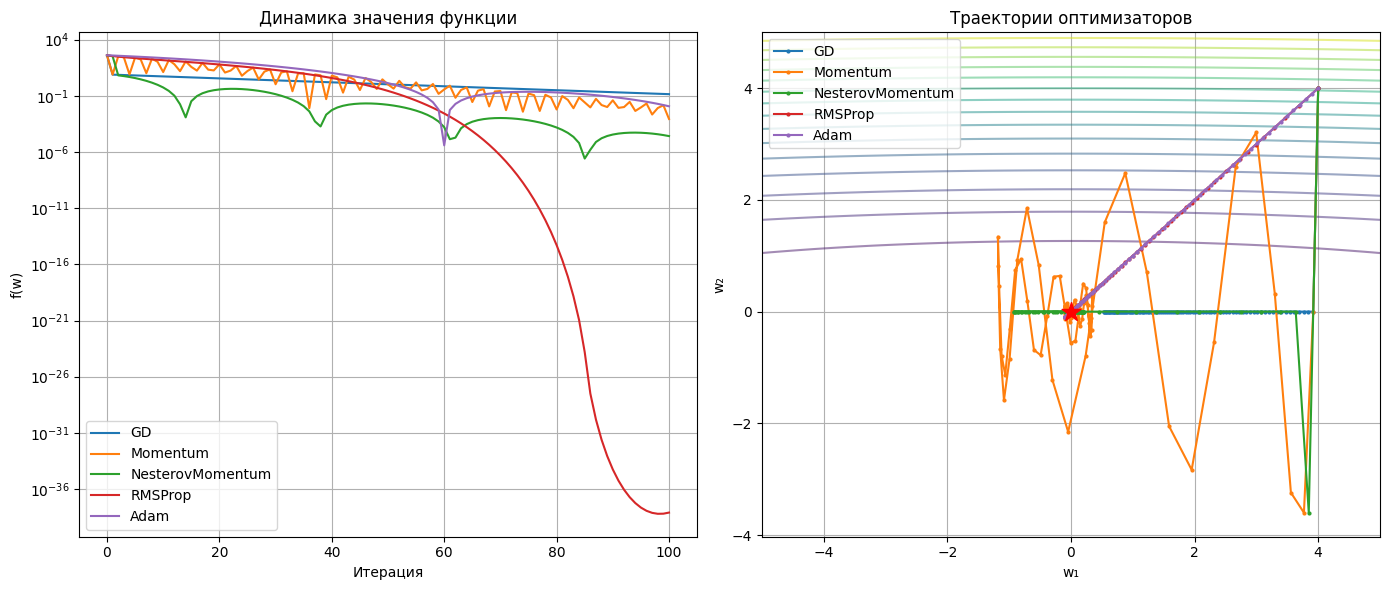

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, f_vals in f_values.items():
    axes[0].plot(f_vals, label=name)

axes[0].set_xlabel("Итерация")
axes[0].set_ylabel("f(w)")
axes[0].set_title("Динамика значения функции")
axes[0].legend()
axes[0].set_yscale("log")

w1 = np.linspace(-5, 5, 100)
w2 = np.linspace(-1, 5, 100)
W1, W2 = np.meshgrid(w1, w2)
Z = 0.5 * (A[0, 0] * W1**2 + A[1, 1] * W2**2)

axes[1].contour(W1, W2, Z, levels=20, alpha=0.5)

for name, traj in trajectories.items():
    axes[1].plot(traj[:, 0], traj[:, 1], "o-", markersize=2, label=name)

axes[1].scatter([0], [0], color="red", marker="*", s=200, zorder=10)
axes[1].set_xlabel("w₁")
axes[1].set_ylabel("w₂")
axes[1].set_title("Траектории оптимизаторов")
axes[1].legend()

plt.tight_layout()
plt.show()

### Выводы по эксперименту A

- **GD** демонстрирует осцилляции вдоль направления с высокой кривизной и медленную сходимость
- **Momentum** и **NesterovMomentum** быстрее достигают минимума за счёт накопления скорости
- **RMSProp** и **Adam** адаптируют шаг для каждой координаты, компенсируя различия в кривизне

## Эксперимент B: Сравнение на линейной регрессии (full-batch, фиксированный lr)

### Цель

Сравнить поведение оптимизаторов при одинаковом learning rate — сравнение с фиксированным LR. 
> **Примечание:** Результаты зависят от выбора LR. Для строгого сравнения требуется подбор гиперпараметров (см. Эксперимент C)..

### Настройка

- Данные: синтетическая регрессия с 10 признаками
- Режим: full-batch (batch_size=None)
- Одинаковый lr=0.01 для всех методов

In [5]:
X_train, X_val, X_test, y_train, y_val, y_test = make_dataset_regression(
    n_samples=1000, n_features=10
)

fixed_lr = 0.01
steps = 500

optimizers_fixed = {
    "GD": GD(lr=fixed_lr),
    "Momentum": Momentum(lr=fixed_lr, momentum=0.9),
    "NesterovMomentum": NesterovMomentum(lr=fixed_lr, momentum=0.9),
    "RMSProp": RMSProp(lr=fixed_lr),
    "Adam": Adam(lr=fixed_lr),
    "AdamW": AdamW(lr=fixed_lr, weight_decay=0.01),
}

results_fixed = {}
for name, opt in optimizers_fixed.items():
    results_fixed[name] = train_and_collect(
        opt, X_train, y_train, X_test, y_test, steps=steps
    )

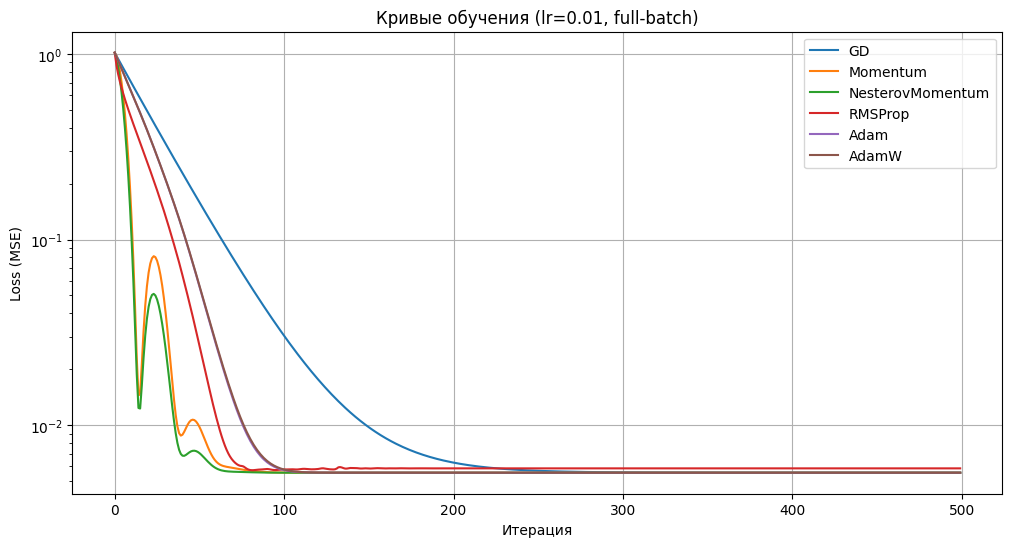

In [6]:
plt.figure(figsize=(12, 6))

for name, result in results_fixed.items():
    plt.plot(result["history"], label=name)

plt.xlabel("Итерация")
plt.ylabel("Loss (MSE)")
plt.title(f"Кривые обучения (lr={fixed_lr}, full-batch)")
plt.legend()
plt.yscale("log")
plt.show()

In [7]:
df_fixed = pd.DataFrame(
    [
        {
            "Оптимизатор": name,
            "Train MSE": f"{r['train_mse']:.6f}",
            "Test MSE": f"{r['test_mse']:.6f}",
            "Train R²": f"{r['train_r2']:.4f}",
            "Test R²": f"{r['test_r2']:.4f}",
            "Время (с)": f"{r['time']:.4f}",
        }
        for name, r in results_fixed.items()
    ]
)

df_fixed

,Оптимизатор,Train MSE,Test MSE,Train R²,Test R²,Время (с)
0,GD,0.005538,0.005750,0.9945,0.9942,0.0073
1,Momentum,0.005538,0.005752,0.9945,0.9942,0.0069
2,NesterovMomentum,0.005538,0.005752,0.9945,0.9942,0.0073
3,RMSProp,0.005845,0.005765,0.9942,0.9942,0.0079
4,Adam,0.005538,0.005752,0.9945,0.9942,0.0093
5,AdamW,0.005538,0.005739,0.9945,0.9943,0.0099


### Важное замечание

Сравнение с одинаковым lr не является корректным — разные оптимизаторы оптимальны при различных значениях learning rate. В следующем эксперименте выполняется подбор lr для каждого метода.

## Эксперимент C: Подбор lr для каждого оптимизатора

### Цель

Сравнение с подбором гиперпараметров оптимизаторов в лучших условиях для каждого метода.

### Настройка

- Сетка lr: [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
- Выбор лучшего lr по test MSE

В этом эксперименте мы подбираем learning rate на валидационной выборке, чтобы сравнение было честным.

In [8]:
lr_grid = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]

opt_configs = [
    ("GD", GD, {}),
    ("Momentum", Momentum, {"momentum": 0.9}),
    ("NesterovMomentum", NesterovMomentum, {"momentum": 0.9}),
    ("RMSProp", RMSProp, {}),
    ("Adam", Adam, {}),
    ("AdamW", AdamW, {"weight_decay": 0.01}),
]

best_results = {}
all_grid_results = {}

for name, opt_class, kwargs in opt_configs:
    df_grid, best = grid_search_lr(
        opt_class,
        lr_grid,
        X_train,
        y_train,
        X_val,
        y_val,
        X_test=X_test,
        y_test=y_test,
        steps=steps,
        **kwargs,
    )
    best_results[name] = best
    all_grid_results[name] = df_grid

In [9]:
df_best = pd.DataFrame(
    [
        {
            "Оптимизатор": name,
            "Best lr": f"{r['lr']:.0e}",
            "Train MSE": f"{r['train_mse']:.6f}",
            "Test MSE": f"{r['test_mse']:.6f}",
            "Train R²": f"{r['train_r2']:.4f}",
            "Test R²": f"{r['test_r2']:.4f}",
            "Время (с)": f"{r['time']:.4f}",
        }
        for name, r in best_results.items()
    ]
)

df_best

,Оптимизатор,Best lr,Train MSE,Test MSE,Train R²,Test R²,Время (с)
0,GD,1e-02,0.005538,0.005750,0.9945,0.9942,0.0065
1,Momentum,1e-03,0.005538,0.005751,0.9945,0.9942,0.0067
2,NesterovMomentum,1e-03,0.005538,0.005751,0.9945,0.9942,0.0072
3,RMSProp,3e-03,0.005565,0.005825,0.9944,0.9942,0.0082
4,Adam,3e-03,0.005552,0.005755,0.9944,0.9942,0.0092
5,AdamW,3e-03,0.005569,0.005745,0.9944,0.9942,0.0097


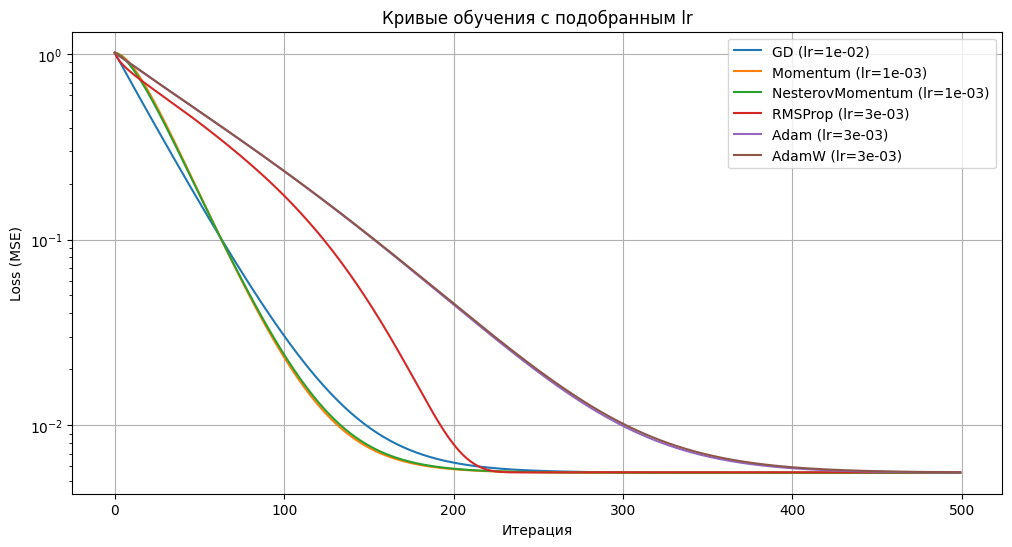

In [10]:
plt.figure(figsize=(12, 6))

for name, opt_class, kwargs in opt_configs:
    best_lr = best_results[name]["lr"]
    opt = opt_class(lr=best_lr, **kwargs)
    result = train_and_collect(
        opt, X_train, y_train, X_test, y_test, steps=steps
    )
    plt.plot(result["history"], label=f"{name} (lr={best_lr:.0e})")

plt.xlabel("Итерация")
plt.ylabel("Loss (MSE)")
plt.title("Кривые обучения с подобранным lr")
plt.legend()
plt.yscale("log")
plt.show()

### Выводы

На выпуклой задаче линейной регрессии с MSE все оптимизаторы способны достичь сопоставимого минимума при адекватно подобранном lr. Различия проявляются в скорости сходимости и чувствительности к гиперпараметрам.

## Эксперимент D: Ill-conditioned задача

### Цель

Продемонстрировать поведение оптимизаторов на задаче с плохой обусловленностью матрицы признаков.

### Настройка

Создаётся матрица X с большим отношением сингулярных чисел путём умножения на диагональную матрицу с разными масштабами.

> **Важно:** Данные генерируются с высоким числом обусловленности (~1e5), чтобы продемонстрировать проблемы простых градиентных методов.

In [11]:
n_samples_ill = 1000
n_features_ill = 10

X_raw, _ = make_regression(
    n_samples=n_samples_ill, n_features=n_features_ill, random_state=SEED
)
scaler_temp = StandardScaler()
X_scaled = scaler_temp.fit_transform(X_raw)

U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)
S_new = np.logspace(0, -5, len(S))
X_ill = U @ np.diag(S_new) @ Vt

true_w = np.random.randn(n_features_ill)
y_ill = X_ill @ true_w + np.random.randn(n_samples_ill) * 0.1

X_train_ill_full, X_test_ill, y_train_ill_full, y_test_ill = train_test_split(
    X_ill, y_ill, test_size=0.2, random_state=SEED
)
X_train_ill, X_val_ill, y_train_ill, y_val_ill = train_test_split(
    X_train_ill_full, y_train_ill_full, test_size=0.25, random_state=SEED
)

y_scaler = StandardScaler()
y_train_ill = y_scaler.fit_transform(y_train_ill.reshape(-1, 1)).flatten()
y_val_ill = y_scaler.transform(y_val_ill.reshape(-1, 1)).flatten()
y_test_ill = y_scaler.transform(y_test_ill.reshape(-1, 1)).flatten()

print(f"Condition number (Train): {np.linalg.cond(X_train_ill):.2e}")

lr_grid = np.logspace(-5, -1, 10)
results_ill_gd, best_ill_gd = grid_search_lr(
    GD,
    lr_grid,
    X_train_ill,
    y_train_ill,
    X_val_ill,
    y_val_ill,
    X_test=X_test_ill,
    y_test=y_test_ill,
    steps=1000,
)

print(f"Best LR for GD: {best_ill_gd['lr']}")

Condition number (Train): 1.05e+05
Best LR for GD: 0.1


In [12]:
steps_ill = 1000

optimizers_ill = {
    "GD": GD(lr=0.01),
    "Momentum": Momentum(lr=0.01, momentum=0.9),
    "NesterovMomentum": NesterovMomentum(lr=0.01, momentum=0.9),
    "RMSProp": RMSProp(lr=0.01),
    "Adam": Adam(lr=0.01),
}

results_ill = {}
for name, opt in optimizers_ill.items():
    results_ill[name] = train_and_collect(
        opt, X_train_ill, y_train_ill, X_test_ill, y_test_ill, steps=steps_ill
    )

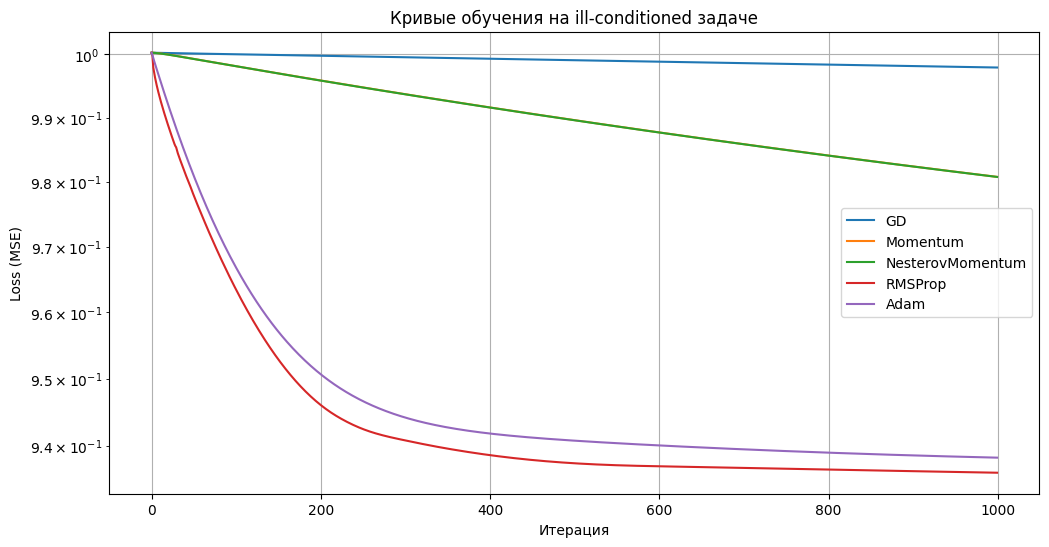

In [13]:
plt.figure(figsize=(12, 6))

for name, result in results_ill.items():
    plt.plot(result["history"], label=name)

plt.xlabel("Итерация")
plt.ylabel("Loss (MSE)")
plt.title("Кривые обучения на ill-conditioned задаче")
plt.legend()
plt.yscale("log")
plt.show()

In [14]:
df_ill = pd.DataFrame(
    [
        {
            "Оптимизатор": name,
            "Test MSE": f"{r['test_mse']:.6f}",
            "Test R²": f"{r['test_r2']:.4f}",
            "Норма весов": f"{r['w_norm']:.4f}",
        }
        for name, r in results_ill.items()
    ]
)

df_ill

,Оптимизатор,Test MSE,Test R²,Норма весов
0,GD,1.151016,-0.0143,0.1441
1,Momentum,1.135007,-0.0002,1.3755
2,NesterovMomentum,1.134996,-0.0002,1.3764
3,RMSProp,1.097029,0.0333,19.1843
4,Adam,1.097024,0.0333,9.6993


### Выводы

- **GD** демонстрирует медленную сходимость из-за плохой обусловленности
- **Momentum** и **NesterovMomentum** ускоряют сходимость вдоль направлений с низкой кривизной
- **RMSProp** и **Adam** адаптируют learning rate для каждой координаты, что эффективно компенсирует различия в масштабах признаков

## Эксперимент E: Mini-batch режим

### Цель

Продемонстрировать влияние стохастичности на поведение оптимизаторов.

### Настройка

- batch_size=32
- Сравнение с оптимальными lr из эксперимента C

> **Примечание:** Используются лучшие LR из full-batch режима. Для стохастического градиентного спуска (SGD) оптимальные LR могут отличаться.

In [15]:
batch_size = 32
steps_mini = 500

results_mini = {}
for name, opt_class, kwargs in opt_configs:
    best_lr = best_results[name]["lr"]
    opt = opt_class(lr=best_lr, **kwargs)
    results_mini[name] = train_and_collect(
        opt,
        X_train,
        y_train,
        X_test,
        y_test,
        steps=steps_mini,
        batch_size=batch_size,
    )

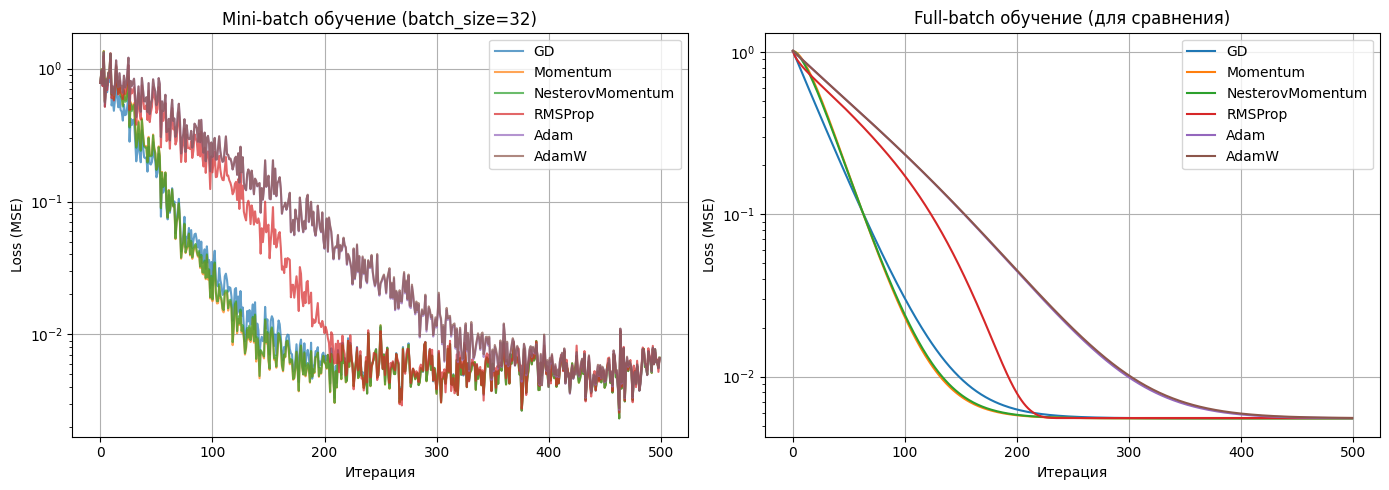

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, result in results_mini.items():
    axes[0].plot(result["history"], label=name, alpha=0.7)

axes[0].set_xlabel("Итерация")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title(f"Mini-batch обучение (batch_size={batch_size})")
axes[0].legend()
axes[0].set_yscale("log")

for name, opt_class, kwargs in opt_configs:
    best_lr = best_results[name]["lr"]
    opt = opt_class(lr=best_lr, **kwargs)
    result_full = train_and_collect(
        opt, X_train, y_train, X_test, y_test, steps=steps_mini
    )
    axes[1].plot(result_full["history"], label=name)

axes[1].set_xlabel("Итерация")
axes[1].set_ylabel("Loss (MSE)")
axes[1].set_title("Full-batch обучение (для сравнения)")
axes[1].legend()
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

In [17]:
df_mini = pd.DataFrame(
    [
        {
            "Оптимизатор": name,
            "Test MSE (mini-batch)": f"{results_mini[name]['test_mse']:.6f}",
            "Test R² (mini-batch)": f"{results_mini[name]['test_r2']:.4f}",
        }
        for name in results_mini.keys()
    ]
)

df_mini

,Оптимизатор,Test MSE (mini-batch),Test R² (mini-batch)
0,GD,0.005783,0.9942
1,Momentum,0.005778,0.9942
2,NesterovMomentum,0.005778,0.9942
3,RMSProp,0.006120,0.9939
4,Adam,0.005836,0.9942
5,AdamW,0.005835,0.9942


### Выводы

- Mini-batch режим добавляет шум в оценку градиента, что проявляется в более шумных кривых обучения
- Адаптивные методы (Adam, RMSProp) демонстрируют большую устойчивость к шуму
- При наличии стохастичности может потребоваться уменьшение learning rate для стабильности

## Эксперимент F: L2-регуляризация vs AdamW weight decay

### Цель

Продемонстрировать различие между L2-регуляризацией в лоссе и decoupled weight decay в AdamW.

### Настройка

Сравнение:
1. Adam без регуляризации
2. Adam с L2-регуляризацией (через параметр reg модели)
3. AdamW с weight decay

In [18]:
X_train_f, X_val_f, X_test_f, y_train_f, y_val_f, y_test_f = (
    make_dataset_regression(n_samples=200, seed=42)
)

X_train, y_train = X_train_f, y_train_f
X_test, y_test = X_test_f, y_test_f
reg_strength = 0.1

model_adam_no_reg = LinearRegression(
    solver="iterative",
    loss=MSE(),
    opt=Adam(lr=0.01),
    steps=500,
    random_state=SEED,
)

model_adam_l2 = LinearRegression(
    solver="iterative",
    loss=MSE(),
    opt=Adam(lr=0.01),
    reg=L2(reg_strength),
    steps=500,
    random_state=SEED,
)

model_adamw = LinearRegression(
    solver="iterative",
    loss=MSE(),
    opt=AdamW(lr=0.01, weight_decay=reg_strength),
    steps=500,
    random_state=SEED,
)

model_adam_no_reg.fit(X_train, y_train)
model_adam_l2.fit(X_train, y_train)
model_adamw.fit(X_train, y_train)

reg_results = {
    "Adam (без рег.)": {
        "history": model_adam_no_reg.history,
        "test_mse": mean_squared_error(
            y_test, model_adam_no_reg.predict(X_test)
        ),
        "test_r2": r2_score(y_test, model_adam_no_reg.predict(X_test)),
        "w_norm": np.linalg.norm(model_adam_no_reg.w),
    },
    "Adam + L2": {
        "history": model_adam_l2.history,
        "test_mse": mean_squared_error(y_test, model_adam_l2.predict(X_test)),
        "test_r2": r2_score(y_test, model_adam_l2.predict(X_test)),
        "w_norm": np.linalg.norm(model_adam_l2.w),
    },
    "AdamW": {
        "history": model_adamw.history,
        "test_mse": mean_squared_error(y_test, model_adamw.predict(X_test)),
        "test_r2": r2_score(y_test, model_adamw.predict(X_test)),
        "w_norm": np.linalg.norm(model_adamw.w),
    },
}

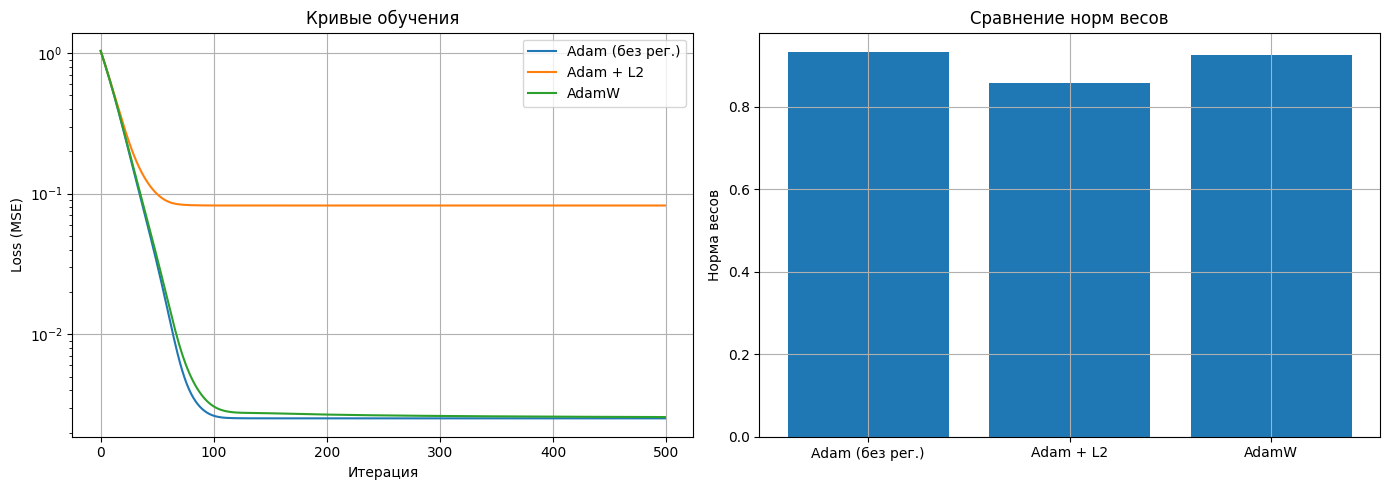

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, result in reg_results.items():
    axes[0].plot(result["history"], label=name)

axes[0].set_xlabel("Итерация")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("Кривые обучения")
axes[0].legend()
axes[0].set_yscale("log")

names = list(reg_results.keys())
w_norms = [reg_results[n]["w_norm"] for n in names]

axes[1].bar(names, w_norms)
axes[1].set_ylabel("Норма весов")
axes[1].set_title("Сравнение норм весов")

plt.tight_layout()
plt.show()

In [20]:
df_reg = pd.DataFrame(
    [
        {
            "Метод": name,
            "Test MSE": f"{r['test_mse']:.6f}",
            "Test R²": f"{r['test_r2']:.4f}",
            "Норма весов": f"{r['w_norm']:.4f}",
        }
        for name, r in reg_results.items()
    ]
)

df_reg

,Метод,Test MSE,Test R²,Норма весов
0,Adam (без рег.),0.003457,0.9968,0.9330
1,Adam + L2,0.014038,0.9870,0.8563
2,AdamW,0.003792,0.9965,0.9264


### Выводы

- L2-регуляризация добавляет штраф в функцию потерь, влияя на adaptive moments в Adam
- AdamW применяет weight decay как отдельную операцию после шага Adam
- При одинаковом коэффициенте оба подхода уменьшают норму весов, но могут давать различные результаты

## Итоговое сравнение

In [21]:
summary_data = []

notes = {
    "GD": "базовый, чувствителен к lr",
    "Momentum": "ускорение, осцилляции",
    "NesterovMomentum": "ускорение, стабильнее",
    "RMSProp": "адаптивный, устойчив",
    "Adam": "адаптивный, универсален",
    "AdamW": "Adam + weight decay",
}

for name in best_results.keys():
    summary_data.append(
        {
            "Оптимизатор": name,
            "Best lr": f"{best_results[name]['lr']:.0e}",
            "Steps": steps,
            "Test MSE": f"{best_results[name]['test_mse']:.6f}",
            "Test R²": f"{best_results[name]['test_r2']:.4f}",
            "Время (с)": f"{best_results[name]['time']:.4f}",
            "Заметки": notes.get(name, ""),
        }
    )

df_summary = pd.DataFrame(summary_data)
df_summary

,Оптимизатор,Best lr,Steps,Test MSE,Test R²,Время (с),Заметки
0,GD,1e-02,500,0.005750,0.9942,0.0065,"базовый, чувствителен к lr"
1,Momentum,1e-03,500,0.005751,0.9942,0.0067,"ускорение, осцилляции"
2,NesterovMomentum,1e-03,500,0.005751,0.9942,0.0072,"ускорение, стабильнее"
3,RMSProp,3e-03,500,0.005825,0.9942,0.0082,"адаптивный, устойчив"
4,Adam,3e-03,500,0.005755,0.9942,0.0092,"адаптивный, универсален"
5,AdamW,3e-03,500,0.005745,0.9942,0.0097,Adam + weight decay


## Выводы

1. **Чувствительность к learning rate**: GD и методы с momentum требуют тщательного подбора lr, тогда как Adam и RMSProp более устойчивы благодаря адаптивности.

2. **Скорость сходимости**: Momentum-методы ускоряют сходимость на хорошо обусловленных задачах. Adam обычно сходится быстрее на практике.

3. **Mini-batch режим**: Адаптивные методы лучше справляются с шумом градиента. При использовании mini-batch может потребоваться уменьшение lr.

4. **Ill-conditioned задачи**: Адаптивные методы эффективно компенсируют различия в масштабах признаков. GD без адаптации сходится существенно медленнее.

5. **AdamW vs Adam + L2**: Decoupled weight decay в AdamW применяется независимо от адаптивных моментов, что может давать лучшие результаты на некоторых задачах.